In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'GH Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'GH Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'GH Starved-Starved'


df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df4['Condition'] = 'SI Fed-Fed'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df5['Condition'] = 'SI Fed-Starved'

df6 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df6['Condition'] = 'SI Starved-Starved'


df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)



si = df[df['Condition'].str.contains('SI')].copy()
gh = df[df['Condition'].str.contains('GH')].copy()


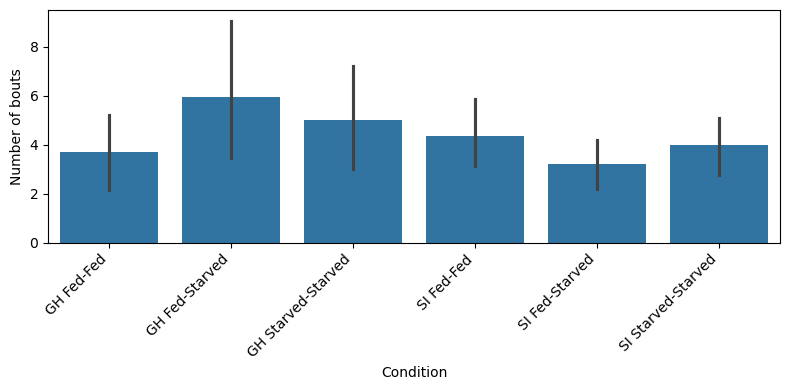

In [2]:
bout_counts = (
    df.groupby(['Condition', 'file'])['bout_id']
      .size()
      .reset_index(name='n_bouts')
)


plt.figure(figsize=(8,4))

sns.barplot(
    data=bout_counts,
    x='Condition',
    y='n_bouts'
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of bouts')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

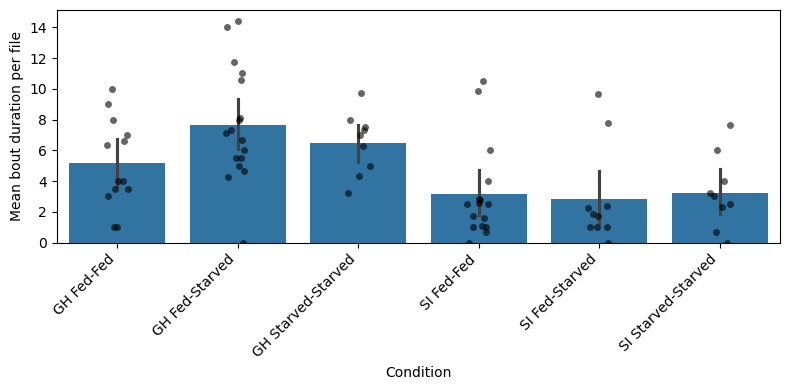

In [3]:
# mean bout duration per file
duration_per_file = (
    df.groupby(['Condition', 'file'])['duration']
      .mean()
      .reset_index(name='mean_bout_duration')
)

plt.figure(figsize=(8,4))

sns.barplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration'
)

sns.stripplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration',
    color='black',
    alpha=0.6
)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean bout duration per file')
plt.xlabel('Condition')

plt.tight_layout()
plt.show()

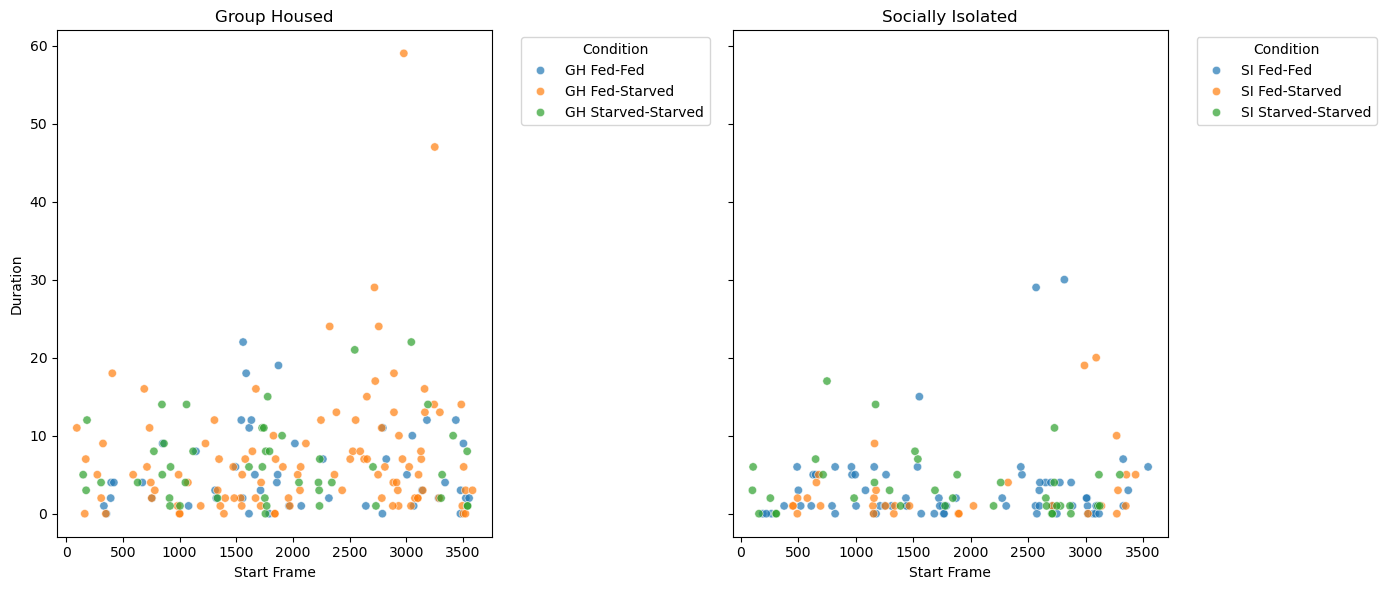

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.scatterplot(
    data=gh,
    x='start_frame',
    y='duration',
    hue='Condition',
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('Start Frame')
axes[0].set_ylabel('Duration')

axes[0].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Socially isolated
sns.scatterplot(
    data=si,
    x='start_frame',
    y='duration',
    hue='Condition',
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('Start Frame')
axes[1].set_ylabel('Duration')

axes[1].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

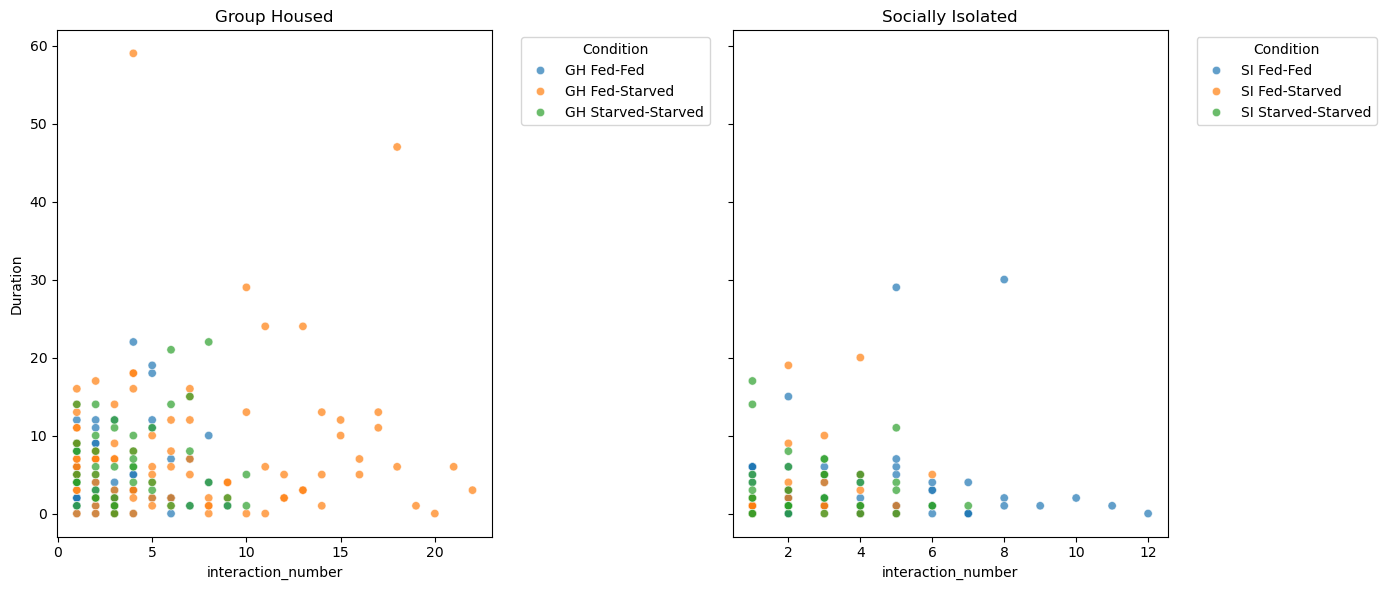

In [6]:
si = si.sort_values(['Condition', 'file', 'start_frame'])
si['interaction_number'] = (
    si.groupby(['Condition', 'file'])
      .cumcount() + 1
)

gh = gh.sort_values(['Condition', 'file', 'start_frame'])
gh['interaction_number'] = (
    gh.groupby(['Condition', 'file'])
      .cumcount() + 1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.scatterplot(
    data=gh,
    x='interaction_number',
    y='duration',
    hue='Condition',
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('interaction_number')
axes[0].set_ylabel('Duration')

axes[0].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Socially isolated
sns.scatterplot(
    data=si,
    x='interaction_number',
    y='duration',
    hue='Condition',
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('interaction_number')
axes[1].set_ylabel('Duration')

axes[1].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


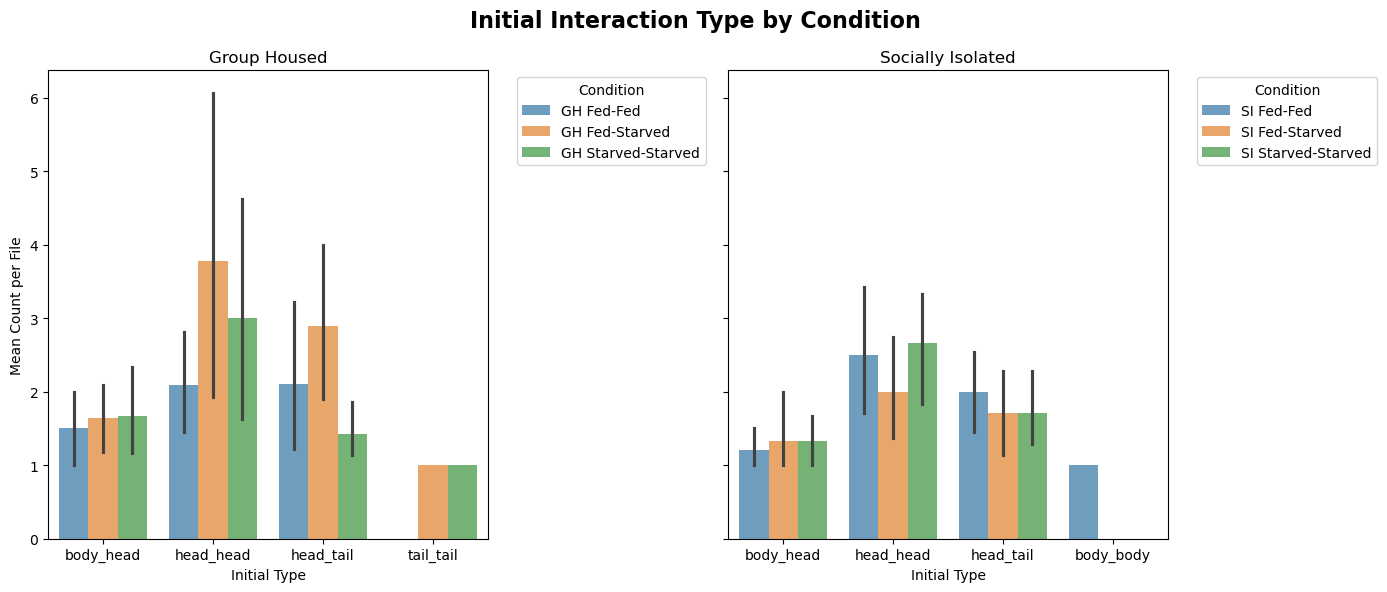

In [12]:
initial_interaction_types = (
    df.groupby(['Condition', 'file', 'initial_type'])
      .size()
      .reset_index(name='count')
)

gh_counts = initial_interaction_types[
    initial_interaction_types['Condition'].str.contains('GH')
]

si_counts = initial_interaction_types[
    initial_interaction_types['Condition'].str.contains('SI')
]



fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.barplot(
    data=gh_counts,
    x='initial_type',
    y='count',
    hue='Condition',
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('Initial Type')
axes[0].set_ylabel('Mean Count per File')

axes[0].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Socially isolated
sns.barplot(
    data=si_counts,
    x='initial_type',
    y='count',
    hue='Condition',
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('Initial Type')
axes[1].set_ylabel('Mean Count per File')

axes[1].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)


fig.suptitle(
    'Initial Interaction Type by Condition',
    fontsize=16,
    fontweight='bold'
)


plt.tight_layout()
plt.show()


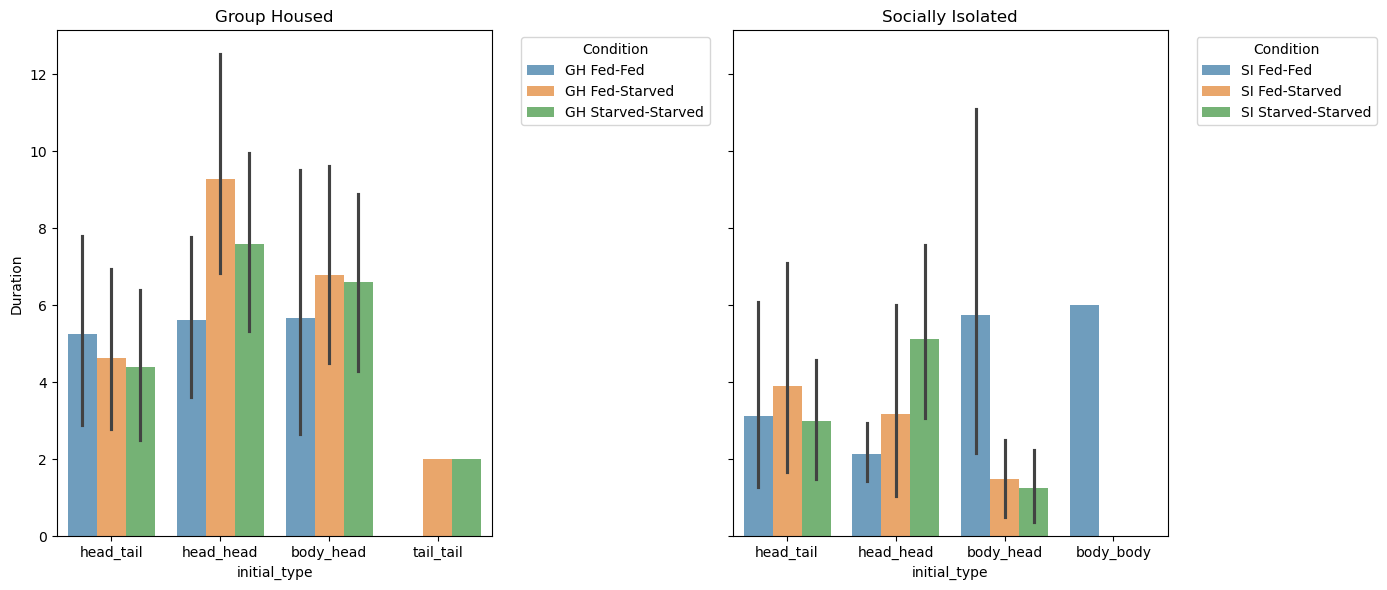

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.barplot(
    data=gh,
    x='initial_type',
    y='duration',
    hue='Condition',
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('initial_type')
axes[0].set_ylabel('Duration')

axes[0].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Socially isolated
sns.barplot(
    data=si,
    x='initial_type',
    y='duration',
    hue='Condition',
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('initial_type')
axes[1].set_ylabel('Duration')

axes[1].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()


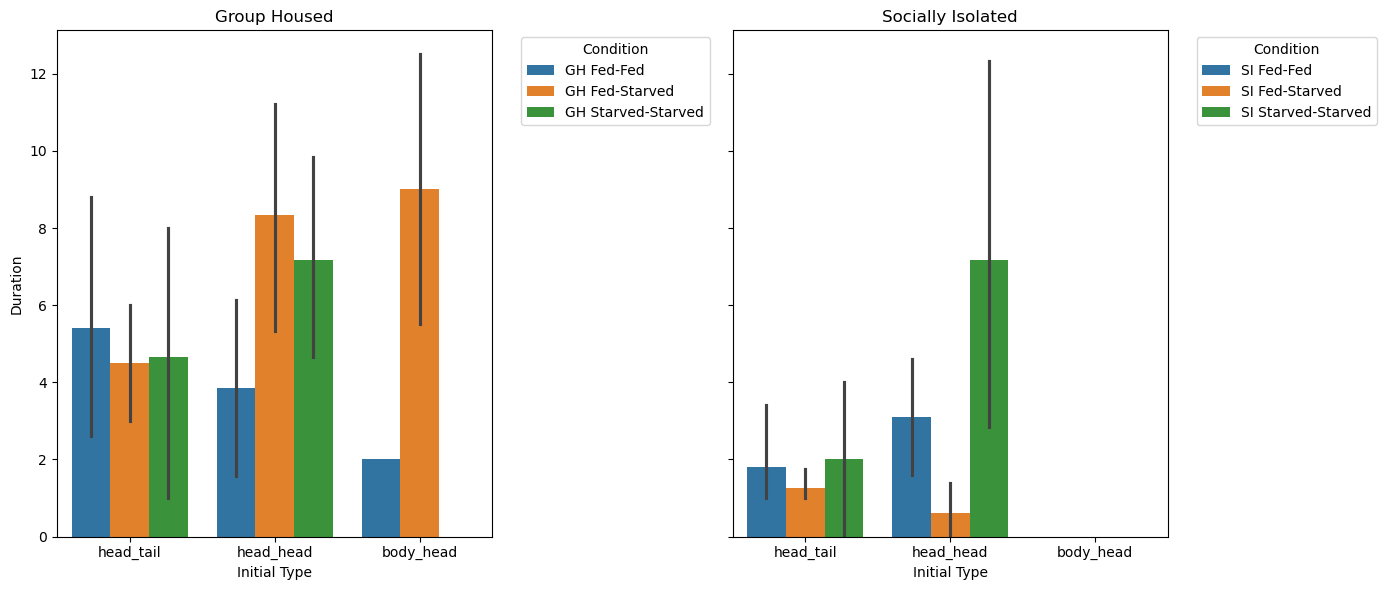

In [9]:
#### this is cool

gh_first = gh[gh['interaction_number'] == 1]
si_first = si[si['interaction_number'] == 1]


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.barplot(
    data=gh_first,
    x='initial_type',
    y='duration',
    hue='Condition',
    ax=axes[0]
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('Initial Type')
axes[0].set_ylabel('Duration')
axes[0].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

# Socially isolated
sns.barplot(
    data=si_first,
    x='initial_type',
    y='duration',
    hue='Condition',
    ax=axes[1]
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('Initial Type')
axes[1].set_ylabel('Duration')
axes[1].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


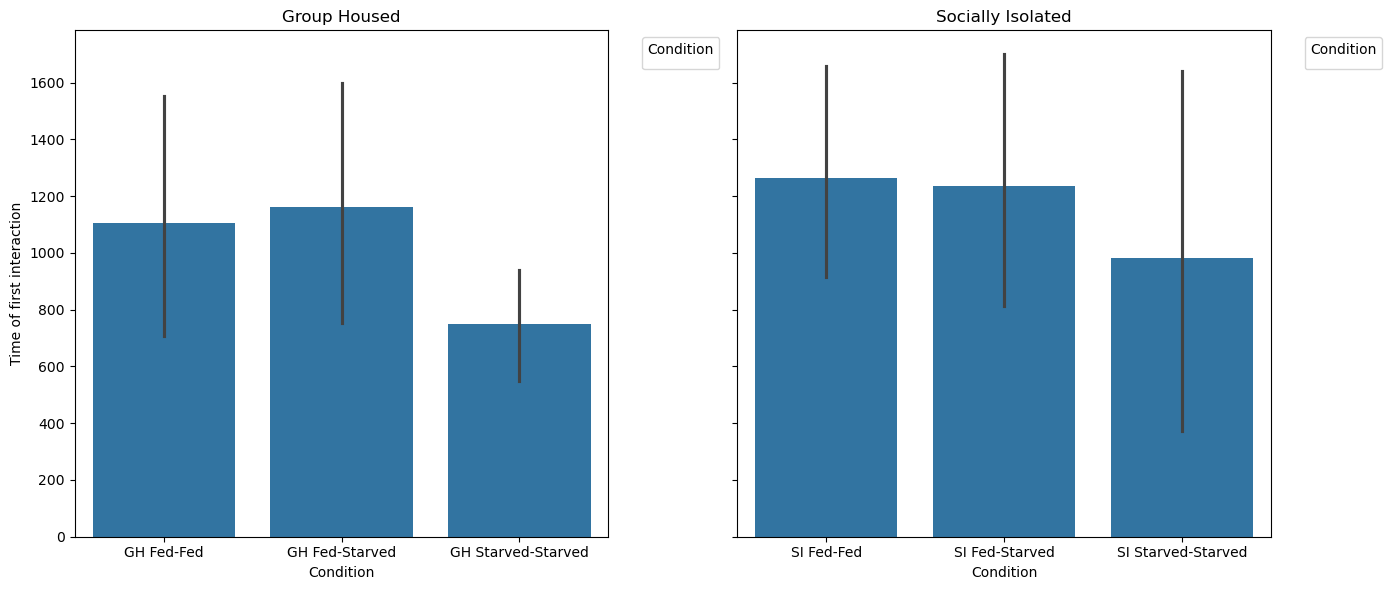

In [10]:
#### this is cool

gh_first = gh[gh['interaction_number'] == 1]
si_first = si[si['interaction_number'] == 1]


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.barplot(
    data=gh_first,
    x='Condition',
    y='start_frame',
    ax=axes[0]
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Time of first interaction')
axes[0].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

# Socially isolated
sns.barplot(
    data=si_first,
    x='Condition',
    y='start_frame',
    ax=axes[1]
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Time of first interaction')
axes[1].legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

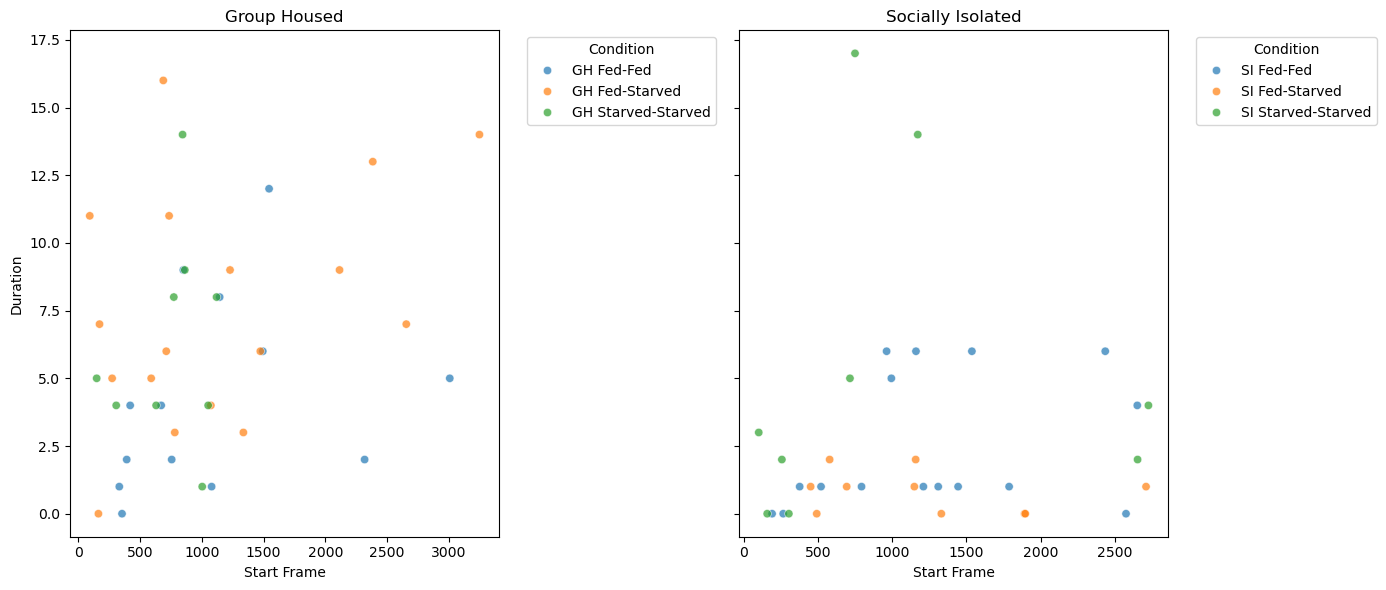

In [22]:
gh_first = gh[gh['interaction_number'] == 1]
si_first = si[si['interaction_number'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Group housed
sns.scatterplot(
    data=gh_first,
    x='start_frame',
    y='duration',
    hue='Condition',
    ax=axes[0],
    alpha=0.7
)

axes[0].set_title('Group Housed')
axes[0].set_xlabel('Start Frame')
axes[0].set_ylabel('Duration')

axes[0].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Socially isolated
sns.scatterplot(
    data=si_first,
    x='start_frame',
    y='duration',
    hue='Condition',
    ax=axes[1],
    alpha=0.7
)

axes[1].set_title('Socially Isolated')
axes[1].set_xlabel('Start Frame')
axes[1].set_ylabel('Duration')

axes[1].legend(
    title='Condition',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

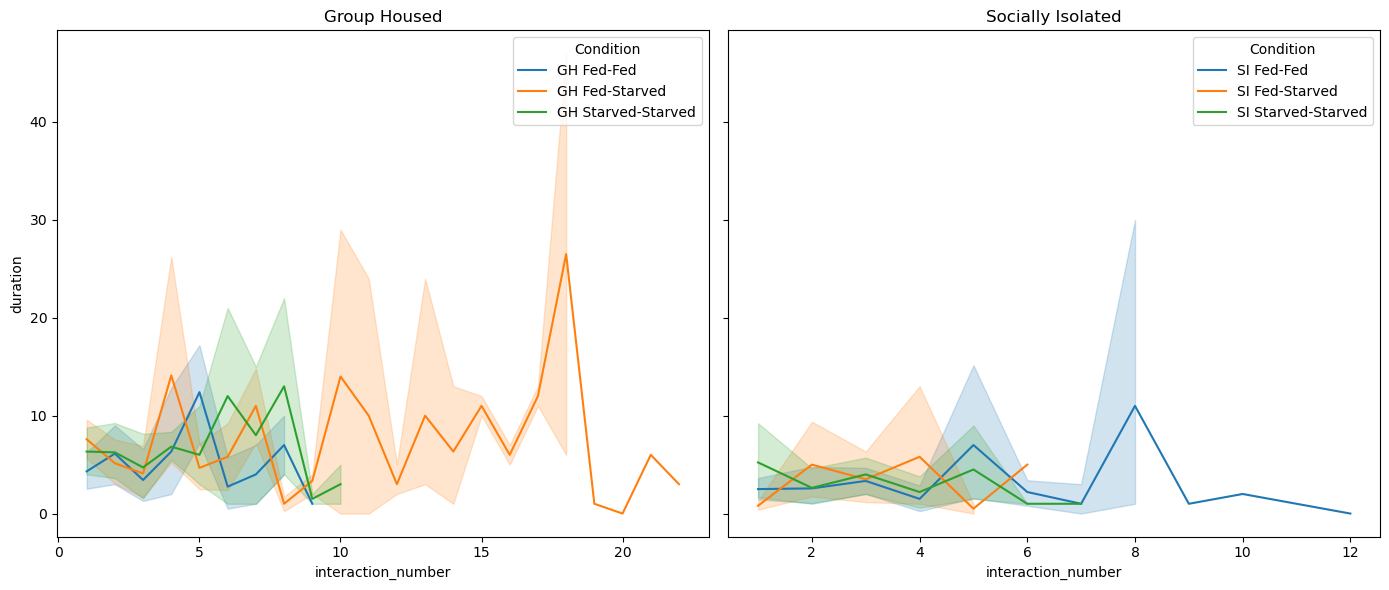

In [21]:
duration_by_interaction = (
    df.groupby(['Condition', 'file', 'interaction_number'])['duration']
      .mean()
      .reset_index()
)


gh_duration = duration_by_interaction[
    duration_by_interaction['Condition'].str.contains('GH')
]

si_duration = duration_by_interaction[
    duration_by_interaction['Condition'].str.contains('SI')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.lineplot(
    data=gh_duration,
    x='interaction_number',
    y='duration',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[0]
)

sns.lineplot(
    data=si_duration,
    x='interaction_number',
    y='duration',
    hue='Condition',
    errorbar=('ci', 95),
    ax=axes[1]
)

axes[0].set_title('Group Housed')
axes[1].set_title('Socially Isolated')



# axes[0].set_xlim(0, 5)
# axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_80331/3724879200.py:36: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_80331/3724879200.py:58: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


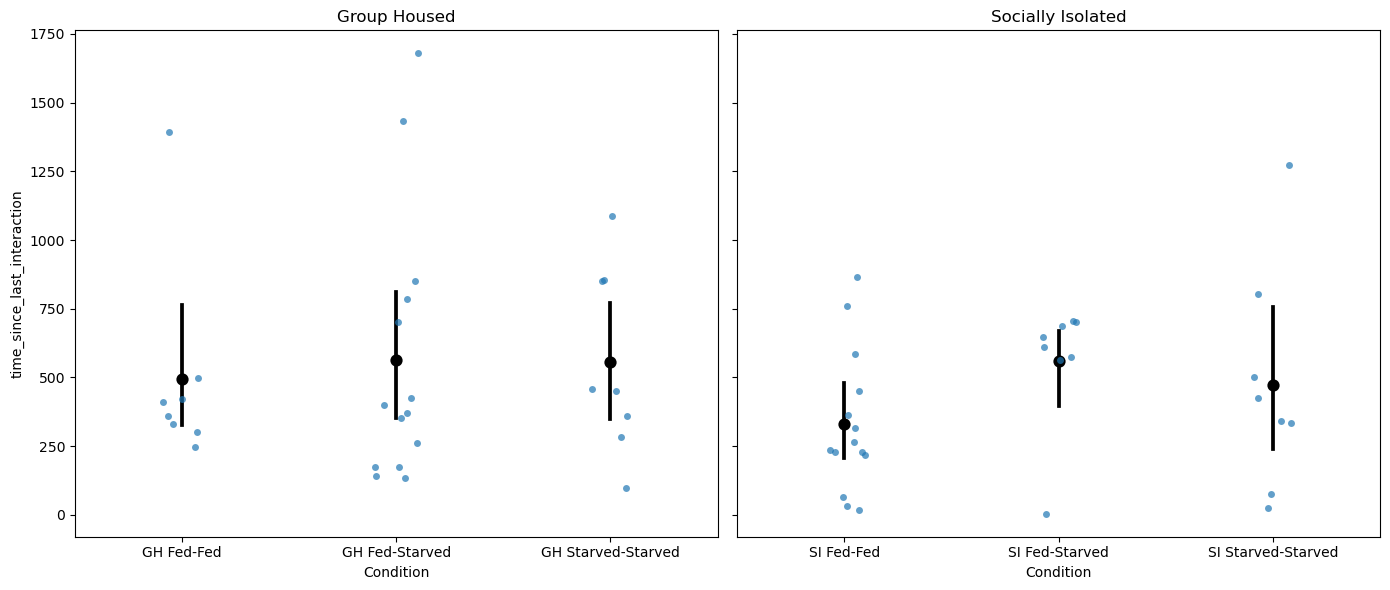

In [18]:
# Calculate time since previous interaction within each file
df = df.sort_values(['Condition', 'file', 'start_frame'])

df['time_since_last_interaction'] = (
    df.groupby(['Condition', 'file'])['start_frame']
      .diff()
)

time_between_file = (
    df.groupby(['Condition', 'file'])['time_since_last_interaction']
      .mean()
      .reset_index()
)

gh_time = time_between_file[
    time_between_file['Condition'].str.contains('GH')
]

si_time = time_between_file[
    time_between_file['Condition'].str.contains('SI')
]


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# GH
sns.stripplot(
    data=gh_time,
    x='Condition',
    y='time_since_last_interaction',
    ax=axes[0],
    jitter=True,
    alpha=0.7
)

sns.pointplot(
    data=gh_time,
    x='Condition',
    y='time_since_last_interaction',
    ax=axes[0],
    errorbar=('ci', 95),
    color='black',
    join=False
)

axes[0].set_title('Group Housed')

# SI
sns.stripplot(
    data=si_time,
    x='Condition',
    y='time_since_last_interaction',
    ax=axes[1],
    jitter=True,
    alpha=0.7
)

sns.pointplot(
    data=si_time,
    x='Condition',
    y='time_since_last_interaction',
    ax=axes[1],
    errorbar=('ci', 95),
    color='black',
    join=False
)

axes[1].set_title('Socially Isolated')

plt.tight_layout()
plt.show()